In [2]:
%load_ext dotenv
%dotenv

In [3]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torch.optim import Adam

import matplotlib.pyplot as plt
import librosa as lr
import re
from pathlib import Path

device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [4]:
SR = 22050
FILES = list(Path('./database/').rglob('*.wav'))

srs = set()
lengths = set()

for f in FILES:
    audio_data, sr = lr.load(f, sr=SR)
    srs.add(sr)
    lengths.add(audio_data.shape[0])

In [5]:
srs, max(lengths)  # We'll reshape our waveforms to be of this maximal length, by adding 0s to the end

({22050}, 116247)

In [6]:
MAX_LENGTH = max(lengths) # Max length of audio clips

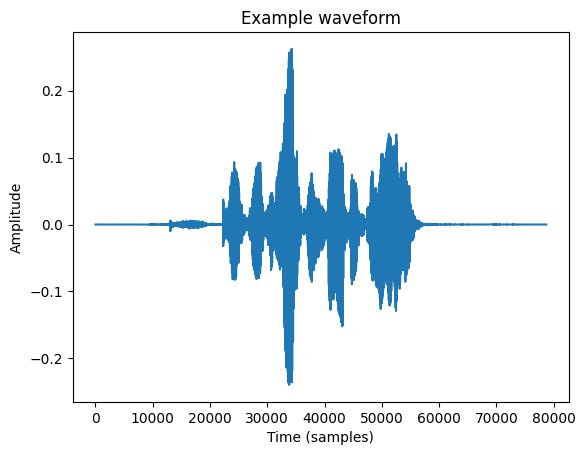

In [7]:
y_test, _ = lr.load(FILES[0], sr=SR)
plt.plot(y_test)
plt.title('Example waveform')
plt.xlabel('Time (samples)')
plt.ylabel('Amplitude')
plt.show()

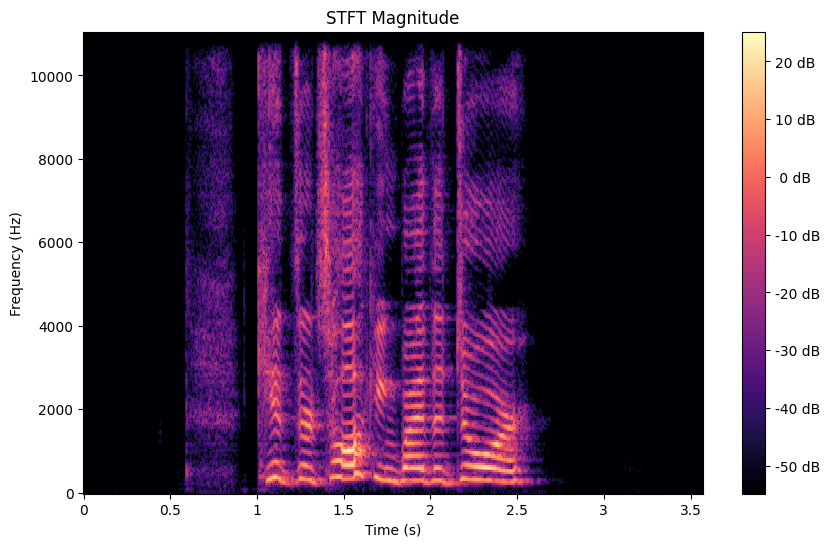

In [8]:
# Let's decompose the waveforms into their frequency components using the Short-Time Fourier Transform (STFT)
audio_data, sr = lr.load(FILES[0], sr=SR)
plt.figure(figsize=(10, 6))
D = lr.stft(audio_data, n_fft=512, hop_length=128)
lr.display.specshow(lr.amplitude_to_db(np.abs(D)), sr=sr, hop_length=128, x_axis='time', y_axis='hz')
plt.title('STFT Magnitude')
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')
plt.colorbar(format='%2.0f dB')
plt.show()

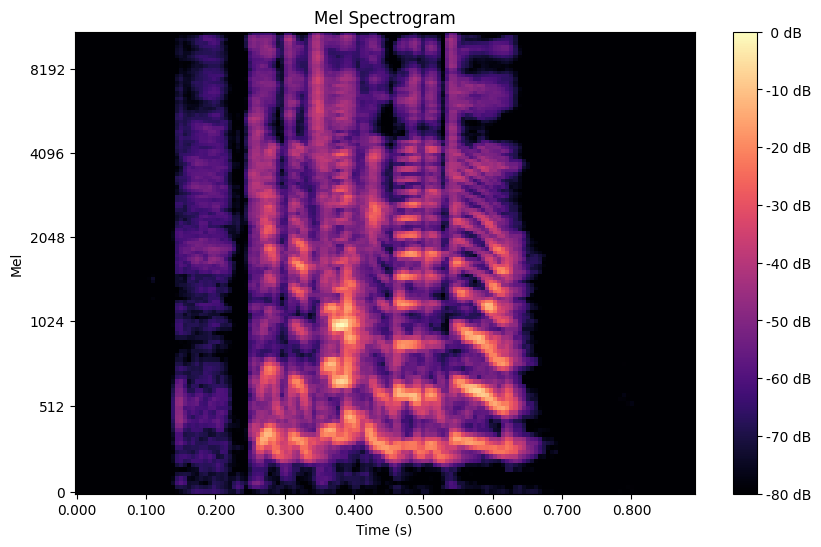

(128, 154)


In [9]:
# Let's plot the Mel spectrogram, which is a more perceptually relevant representation of the frequency content of the audio
plt.figure(figsize=(10, 6))
mel_spec = lr.feature.melspectrogram(y=audio_data, sr=SR, n_mels=128)
mel_db = lr.power_to_db(mel_spec, ref=np.max)
lr.display.specshow(mel_db, sr=SR, hop_length=128, x_axis='time', y_axis='mel')
plt.title('Mel Spectrogram')
plt.xlabel('Time (s)')
plt.ylabel('Mel')
plt.colorbar(format='%2.0f dB')
plt.show()

print(mel_spec.shape)  # This is a 2D array of shape (n_mels, n_frames)

In [10]:
class AudioDataset(Dataset):
    def __init__(self, file_paths, max_length):
        self.file_paths = file_paths
        self.max_length = max_length
        super().__init__()

    def __len__(self):
        return len(self.file_paths)

    @staticmethod
    def load_audio(file: Path) -> np.ndarray:
        audio_data, sr = lr.load(file, sr=SR, mono=True)
        audio_data, _ = lr.effects.trim(audio_data)  # Remove leading and trailing silence
        if len(audio_data) < MAX_LENGTH:
            audio_data = np.pad(audio_data, (0, MAX_LENGTH - len(audio_data)), mode='constant')
        else:
            audio_data = audio_data[:MAX_LENGTH]
        mel = lr.feature.melspectrogram(
            y=audio_data,
            n_mels=128,
            n_fft=1024,
            hop_length=512,
            fmin=50,
            fmax=8000
        )
        mel_db = lr.power_to_db(mel, ref=np.max)  # Convert to decibel scale from power
        mel_norm = (mel_db - mel_db.min()) / (mel_db.max() - mel_db.min() + 1e-9)  # Normalize to [0, 1]
        return mel_norm

    def __getitem__(self, idx):
        fname: Path = self.file_paths[idx]
        if not re.match(r'^(\d+)-(\d+)-(\d+)-(\d+)-(\d+)-(\d+)-(\d+)\.wav$', fname.name):
            raise ValueError(f"Filename {fname} does not match expected format")
        o = list(map(int, fname.stem.split('-')))
        # [modality, channel, emotion, intensity, statement, reptition, actor]
        return self.load_audio(fname), o[2] - 1  # Just return the emotion label

dataset = AudioDataset(FILES, MAX_LENGTH)

In [11]:
x, emotion = dataset[100]  # Each sample is a 1D tensor of length max_length and a 1D tensor of length 7 (the labels)
print(x.shape, emotion)

(128, 228) 5


In [12]:
def train(model, train_dataloader, val_dataloader,epochs=10):
    optimizer = Adam(model.parameters())
    criterion = nn.CrossEntropyLoss()

    L1 = len(train_dataloader)
    L2 = len(val_dataloader)

    tr_losses = []
    vl_losses = []

    for epoch in range(epochs):
        model.train()
        tr = 0
        for x, y in train_dataloader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            outputs = model(x.unsqueeze(1))  # Add channel dimension
            loss = criterion(outputs, y)
            loss.backward()
            optimizer.step()
            tr += loss.item()
        tr_losses.append(tr / L1)
        print(f"Epoch {epoch+1}/{epochs}, Loss: {tr/L1:.4f}", end=" ")
    
        model.eval()
        # Use a separate loop for validation to avoid mixing training and validation losses
        vl = 0
        with torch.no_grad():
            for x, y in val_dataloader:
                x, y = x.to(device), y.to(device)
                outputs = model(x.unsqueeze(1))  # Add channel dimension
                loss = criterion(outputs, y)
                vl += loss.item()
        vl_losses.append(vl / L2)
        print(f"Validation Loss: {vl_losses[-1]:.4f}")

    return tr_losses, vl_losses

In [13]:
test_data, train_data, val_data = torch.utils.data.random_split(dataset, [int(0.7 * len(dataset)), int(0.2 * len(dataset)), len(dataset) - int(0.7 * len(dataset)) - int(0.2 * len(dataset))])
train_dataloader = DataLoader(train_data, batch_size=32, shuffle=True, pin_memory=True)
test_dataloader = DataLoader(test_data, batch_size=32, shuffle=True, pin_memory=True)
val_dataloader = DataLoader(val_data, batch_size=32, shuffle=True, pin_memory=True)

In [14]:
class CNNClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout(0.2),
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout(0.2),
            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout(0.2),
            nn.Flatten(),
            nn.Linear(28672, 512),
            nn.ReLU(),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, 8),  # 8 emotion classes
        )

    def forward(self, x):
        x = self.layers(x) # Add a channel dimension
        return x

Epoch 1/40, Loss: 2.4040 Validation Loss: 2.0866
Epoch 2/40, Loss: 2.0574 Validation Loss: 2.0256
Epoch 3/40, Loss: 1.9946 Validation Loss: 1.9995
Epoch 4/40, Loss: 1.9625 Validation Loss: 2.0170
Epoch 5/40, Loss: 1.8733 Validation Loss: 1.8597
Epoch 6/40, Loss: 1.7793 Validation Loss: 1.8304
Epoch 7/40, Loss: 1.7263 Validation Loss: 1.8424
Epoch 8/40, Loss: 1.6839 Validation Loss: 1.8274
Epoch 9/40, Loss: 1.6282 Validation Loss: 1.6418
Epoch 10/40, Loss: 1.7471 Validation Loss: 2.2711
Epoch 11/40, Loss: 1.6138 Validation Loss: 1.6414
Epoch 12/40, Loss: 1.4955 Validation Loss: 1.5835
Epoch 13/40, Loss: 1.3810 Validation Loss: 1.5859
Epoch 14/40, Loss: 1.3574 Validation Loss: 1.8852
Epoch 15/40, Loss: 1.3029 Validation Loss: 1.5251
Epoch 16/40, Loss: 1.2687 Validation Loss: 1.5845
Epoch 17/40, Loss: 1.2545 Validation Loss: 1.5971
Epoch 18/40, Loss: 1.1514 Validation Loss: 1.4082
Epoch 19/40, Loss: 1.0579 Validation Loss: 1.5721
Epoch 20/40, Loss: 0.9490 Validation Loss: 1.7849
Epoch 21/

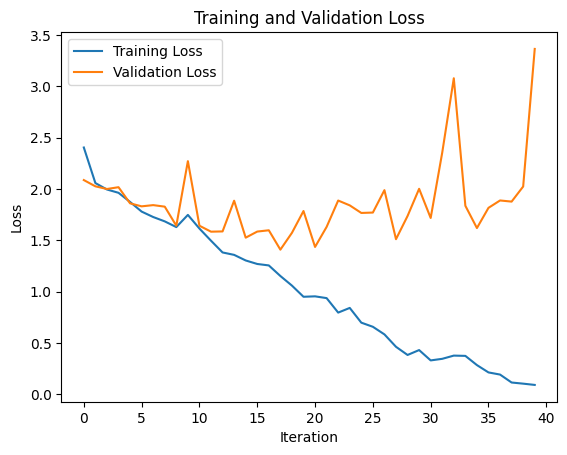

In [15]:
model = CNNClassifier().to(device)
tr_losses, vl_losses = train(model, train_dataloader, val_dataloader, epochs=40)

# Plot losses
plt.plot(tr_losses, label='Training Loss')
plt.plot(vl_losses, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [16]:
# Test accuracy:
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for x, y in test_dataloader:
        x, y = x.to(device), y.to(device)
        outputs = model(x.unsqueeze(1))  # Add channel dimension
        _, predicted = torch.max(outputs.data, 1)
        total += y.size(0)
        correct += (predicted == y).sum().item()
print(f'Test Accuracy: {correct / total:.2f}')

Test Accuracy: 0.55


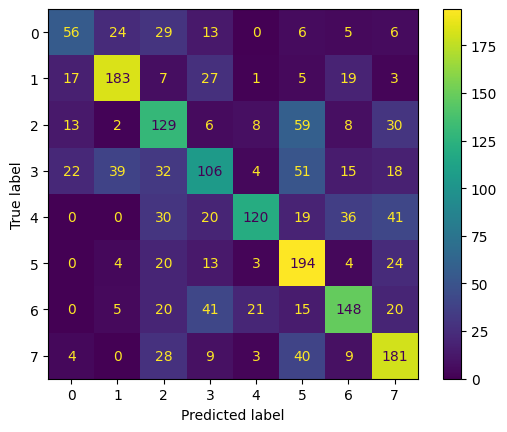

In [17]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_true = []
y_pred = []
with torch.no_grad():
    for x, y in test_dataloader:
        x, y = x.to(device), y.to(device)
        outputs = model(x.unsqueeze(1))  # Add channel dimension
        _, predicted = torch.max(outputs.data, 1)
        y_true.extend(y.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

In [18]:
# import whisper
# model = whisper.load_model("base")

# T = {
#     f.stem: model.transcribe(f.as_posix())['text'] for f in FILES
# }

In [19]:
import json

# with open('transcripts.json', 'w') as f:
#     json.dump(T, f)

with open('transcripts.json', 'r') as f:
    T = json.load(f)

In [20]:
from numpy import dtype
from torchtext.data.utils import get_tokenizer


vocab = []
t = get_tokenizer('basic_english')
for k in T.values():
    vocab.extend(t(k))
unique = set(vocab)
print(f"Unique tokens in transcripts: {len(unique)}")
print(unique)
vocab_dict = {token: idx for idx, token in enumerate(unique)}
def tokenizer(x):
    return torch.tensor([vocab_dict[token] for token in t(x)], dtype=torch.long)

VOCAB_SIZE = len(unique)

Unique tokens in transcripts: 68
{'a', '.', '!', 'and', 'sitting', 'docs', "'", 'were', 'their', '?', 'ducks', 'siting', 'cates', 'these', 'are', 'behind', 'pay', '92', 'buy', 'talking', 'is', 'well', 'it', 'oh', 'dr', 'tox', 'about', 'keep', 'talk', ',', 'attacking', 'her', 'doctor', 'setting', 'keeps', 'you', 'darks', 'dogs', 'guards', 'cutes', 'the', 'don', 'by', 'my', 'does', 'good', 'door', 'okay', 're', 'he', 'who', 'get', 'so', 'talks', 'there', 't', 'dog', 'for', 'they', 'kiss', 'kids', 's', 'at', 'right', 'ah', 'thanks', 'ogsets', 'huck'}


In [21]:
tokenizer('Dogs are sitting by the door')

tensor([37, 14,  4, 42, 40, 46])

In [22]:
class AudioTranscriptDataset(Dataset):
    def __init__(self, transcripts):
        self.transcripts = list(transcripts.items())
        self.tokenizer = tokenizer
        super().__init__()

    def __len__(self):
        return len(self.transcripts)

    def __getitem__(self, idx):
        fname, transcript = self.transcripts[idx]
        o = list(map(int, fname.split('-')))
        # [modality, channel, emotion, intensity, statement, reptition, actor]
        
        return self.tokenizer(transcript), torch.Tensor([o[2] - 1])  # Just return the emotion label

In [23]:
def collate_fn(batch):
    # batch = [(seq_tensor_1, label_1), (seq_tensor_2, label_2), ...]
    sequences, labels = zip(*batch)     # two tuples of tensors
    padded = nn.utils.rnn.pad_sequence(
        sequences,                  # list/tuple of (T_i,) tensors
        batch_first=True,           # output shape: (B, T_max)
        padding_value=0             # PAD_IDX = 0
    )                               # → (B, T_max)

    lengths = torch.tensor([len(s) for s in sequences])  # (B,) — needed for pack_padded
    labels  = torch.stack(list(labels))                   # (B,)

    return padded, labels.squeeze().to(torch.long)

In [24]:
T_dataset = AudioTranscriptDataset(T)
ttrain_dataset, tval_dataset, ttest_dataset = torch.utils.data.random_split(T_dataset, [int(0.7 * len(T_dataset)), int(0.2 * len(T_dataset)), len(T_dataset) - int(0.7 * len(T_dataset)) - int(0.2 * len(T_dataset))])
ttrain_dataloader = DataLoader(ttrain_dataset, batch_size=32, shuffle=True, pin_memory=True, collate_fn=collate_fn)
tval_dataloader = DataLoader(tval_dataset, batch_size=32, shuffle=True, pin_memory=True, collate_fn=collate_fn)
ttest_dataloader = DataLoader(ttest_dataset, batch_size=32, shuffle=True, pin_memory=True, collate_fn=collate_fn)

In [25]:
for x, y in ttrain_dataloader:
    print(x.shape, y.shape)
    break

torch.Size([32, 7]) torch.Size([32])


In [26]:
class RNNClassifier(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super().__init__()
        self.embedding = nn.Embedding(num_embeddings=VOCAB_SIZE, embedding_dim=input_size)  # Adjust num_embeddings as needed
        self.rnn = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)


    def forward(self, x):
        x = x.squeeze(1)
        x = self.embedding(x)
        _, (hn, _) = self.rnn(x)
        out = self.fc(hn[-1])
        return out

Epoch 1/100, Loss: 2.0612 Validation Loss: 2.0420
Epoch 2/100, Loss: 2.0136 Validation Loss: 2.0276
Epoch 3/100, Loss: 2.0045 Validation Loss: 2.0323
Epoch 4/100, Loss: 2.0060 Validation Loss: 2.0330
Epoch 5/100, Loss: 1.9909 Validation Loss: 2.0267
Epoch 6/100, Loss: 1.9938 Validation Loss: 2.0195
Epoch 7/100, Loss: 1.9930 Validation Loss: 2.0255
Epoch 8/100, Loss: 1.9882 Validation Loss: 2.0173
Epoch 9/100, Loss: 1.9908 Validation Loss: 2.0228
Epoch 10/100, Loss: 1.9885 Validation Loss: 2.0166
Epoch 11/100, Loss: 1.9848 Validation Loss: 2.0241
Epoch 12/100, Loss: 1.9839 Validation Loss: 2.0250
Epoch 13/100, Loss: 1.9848 Validation Loss: 2.0279
Epoch 14/100, Loss: 1.9783 Validation Loss: 2.0290
Epoch 15/100, Loss: 1.9829 Validation Loss: 2.0134
Epoch 16/100, Loss: 1.9803 Validation Loss: 2.0151
Epoch 17/100, Loss: 1.9877 Validation Loss: 2.0159
Epoch 18/100, Loss: 1.9818 Validation Loss: 2.0153
Epoch 19/100, Loss: 1.9852 Validation Loss: 2.0276
Epoch 20/100, Loss: 1.9811 Validation Lo

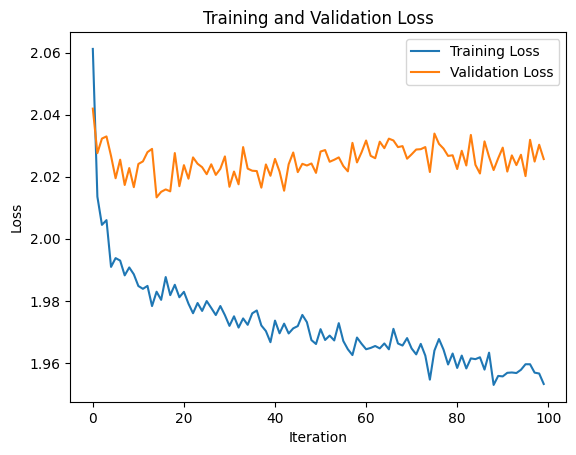

In [27]:
RNNmodel = RNNClassifier(input_size=768, hidden_size=128, num_classes=8).to(device)
tr_losses, vl_losses = train(RNNmodel, ttrain_dataloader, tval_dataloader, epochs=100)

# Plot losses
plt.plot(tr_losses, label='Training Loss')
plt.plot(vl_losses, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [28]:
# Training accuracy

RNNmodel.eval()
correct = 0
total = 0
with torch.no_grad():
    for x, y in ttrain_dataloader:
        x, y = x.to(device), y.to(device)
        outputs = RNNmodel(x.unsqueeze(1))  # Add channel dimension
        _, predicted = torch.max(outputs.data, 1)
        total += y.size(0)
        correct += (predicted == y).sum().item()
print(f'Training Accuracy: {correct / total:.2f}')

Training Accuracy: 0.20


In [40]:
class CombinedDataset(Dataset):
    def __init__(self, transcript_dict):
        self.transcript_dict = list(transcript_dict.items())
        super().__init__()

    def __len__(self):
        return len(self.transcript_dict)

    def __getitem__(self, idx):
        item = self.transcript_dict[idx]
        fname = item[0]
        transcript = item[1]
        o = list(map(int, fname.split('-')))
        # [modality, channel, emotion, intensity, statement, reptition, actor]
        return (AudioDataset.load_audio(f"database/Actor_{o[6]:02d}/{fname}.wav"), tokenizer(transcript)), o[2] - 1

comb_dataset = CombinedDataset(T)

def combined_dataset_collate(batch):
    # batch = [(seq_tensor_1, label_1), (seq_tensor_2, label_2), ...]
    audios = torch.tensor(np.array([b[0][0] for b in batch]))
    transcripts = [b[0][1] for b in batch]
    labels = torch.tensor([b[1] for b in batch])
    padded = nn.utils.rnn.pad_sequence(
        transcripts,                  # list/tuple of (T_i,) tensors
        batch_first=True,           # output shape: (B, T_max)
        padding_value=0             # PAD_IDX = 0
    )                               # → (B, T_max)

    labels  = torch.stack(list(labels))                   # (B,)

    return (audios, padded), labels.squeeze().to(torch.long)

comb_dataloader = DataLoader(comb_dataset, batch_size=32, shuffle=True, pin_memory=True, collate_fn=combined_dataset_collate)

In [41]:
# Late fusion of CNN and RNN

model.eval()
RNNmodel.eval()

correct = 0
total = 0
for (audio_batch, transcript_batch), labels in comb_dataloader:
    cnn_preds = model(audio_batch.unsqueeze(1).to(device))  # Add channel dimension
    rnn_preds = RNNmodel(transcript_batch.to(device))
    combined_preds = 0.8 * cnn_preds + 0.2 * rnn_preds  # 80/20 weightage for late fusion
    _, predicted = torch.max(combined_preds.data, 1)
    total += labels.size(0)
    correct += (predicted.cpu() == labels.cpu()).sum().item()
print(f'Late Fusion Test Accuracy: {correct / total:.2f}')

Late Fusion Test Accuracy: 0.64
